# 01b · Does a region need this partner, or any partner?

*Companion to task 01. Reads nothing from it and writes nothing it depends on -- a
self-contained control for the ladder's central claim.*

The ladder asks whether a region reproduces its own trajectories better inside the network
than alone, and finds that it does. But a "pair" network has strictly more parameters than
a "single" network, so part of that gain could be generic extra capacity -- a second
recurrent block helping regardless of what it represents -- rather than anything specific
to the partner region's identity. This task builds the matched control: every region's
units are split into two independent, non-overlapping halves ("a" and "b"), each with its
own PCA fit from scratch, so a **self-pair** (an area with an independent half of itself)
has exactly the architecture and parameter count of a **cross-pair** (two different areas)
-- the only thing that differs is whether the partner's target carries that area's actual
information or an independent draw of the same area's own.

Four regions give **ten unique two-block networks**: four self-pairs and six cross-pairs.
Each network is scored on both of its blocks, filling a **4x4 matrix of 16 (scored region,
partner) cells** from those ten fits. If a region reproduces itself equally well paired
with itself as paired with a real different area, the ladder's "the network helps" result
is mostly capacity; if cross-pairs reliably beat self-pairs, the partner's identity
matters -- and this task also asks *for which fixation type* and *for which region* that
is truest.

**Design.** Two disjoint halves per region per seed (matching the noise-ceiling split-half
convention already used elsewhere), five seeds to start -- 50 fits -- with the grid
written so a later run can extend to ten without touching anything already trained. Every
fit uses the same recipe as the rest of the final series: minimax objective, 40 units per
block, full dense connectivity (no rank bottleneck -- this task is about identity, not
dimensionality), lr 3e-4 cosine, tanh, spectral radius 1.1, 100k iterations.

| Section | |
|---|---|
| 1 | The grid, and where its data live |
| 2 | Run state and submission (off by default) |
| 3 | Convergence and the matched ceiling |
| 4 | The 4x4 matrix: does a region need this partner, or any partner? |
| 5 | Which fixation type is most affected? |
| 6 | Which region -- or which pair -- is most affected? |
| 7 | What the fits look like |
| 8 | A rank-bottleneck sweep: is spare capacity hiding the effect? |
| 9 | Does tightening the channel affect a particular region or fixation type more? |
| 10 | Region-pair size asymmetry: does a tight cross-region channel cost more for mismatched pairs? |
| 11 | Reading the result |

**Nothing here submits a job unless `SUBMIT` or `SUBMIT_BOTTLENECK` is set to `True`.**

In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_chapter as ch
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_ensemble as ens
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_partner_identity as pid
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_protocol as protocol
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_sweep as sweep
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_synthesis as syn
from dal_monte_2022_analysis.ephys.plotting import fixation_mrnn_ensemble as eviz
from dal_monte_2022_analysis.ephys.plotting import fixation_mrnn_partner_identity as pviz
from dal_monte_2022_analysis.ephys.plotting.thesis_common import (
    CONDITION_SHORT_LABELS, REGION_LABELS, ThesisFigureSettings, apply_thesis_plot_style,
    figure_to_png_bytes, save_thesis_figure,
)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
apply_thesis_plot_style(load_config(repo_root / "configs" / "plotting.yaml"))
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

TREE = "final"
TASK_ROOT = sweep.resolve_task_root("01b_partner_identity", DATASET_CFG_PATH, tree=TREE)
FIGURE_DIR = syn.resolve_output_dir(DATASET_CFG_PATH, scope="final_01b_partner_identity")
FIGURES = ThesisFigureSettings(output_dir=FIGURE_DIR)
COND = CONDITION_SHORT_LABELS

#: Five seeds now; room to extend to ten later just by adding seeds here -- every
#: already-trained cell is skipped on resubmission (`skip_existing` in job_commands).
N_SEEDS = 5
ARCHITECTURES = pid.partner_identity_architectures()
SEEDS = protocol.protocol_seeds(n_seeds=N_SEEDS)
EPOCHS = 100_000

UNIT_CEILING_PATH = repo_root.parent / "local_data" / "dal_monte_2022" / "analysis_outputs" / "ephys" / "psth" / "fixation_noise_ceiling" / "unit_noise_ceiling.pkl"


def show(figure, stem: str) -> None:
    save_thesis_figure(figure, FIGURES, stem)
    display(Image(data=figure_to_png_bytes(figure, dpi=190)))
    plt.close(figure)


def cached(name: str, build):
    path = TASK_ROOT / "tables" / f"{name}.csv"
    if path.exists() and path.stat().st_size > 1:
        frame = pd.read_csv(path)
        if "seed" in frame.columns:
            frame["seed"] = frame["seed"].astype(str)
        return frame
    frame = build()
    if frame is not None and len(frame):
        path.parent.mkdir(parents=True, exist_ok=True)
        frame.to_csv(path, index=False)
    return frame


def md(text: str) -> None:
    display(Markdown(text))


print(f"{len(ARCHITECTURES)} architectures x {len(SEEDS)} seeds = {len(ARCHITECTURES) * len(SEEDS)} cells")
print("task root:", TASK_ROOT)

10 architectures x 5 seeds = 50 cells
task root: /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/final/01b_partner_identity


## 1. The grid, and where its data live

Every architecture is one of ten unique two-block networks; every seed draws its own
independent 50/50 split of each region's units (`write_relabelled_dataset`, called once per
seed, writes a relabelled copy of the combined fixation PSTH export with eight virtual
regions -- `<region>_a`, `<region>_b` -- in place of the four canonical ones, plus a
`halves.json` recording exactly which units went into which half). A region's target is
bit-identical everywhere it appears within a seed, the same guarantee the ladder gives its
four canonical regions: the normalisation scale is pooled over all eight virtual regions of
a seed regardless of which two a given architecture trains on.

In [2]:
table = pd.DataFrame([{"label": a.label, "arm": a.arm, "scored_region": a.scored_region,
                       "partner_region": a.partner_region, "virtual_regions": " + ".join(a.virtual_regions())}
                      for a in ARCHITECTURES])
display(table)
cells = pid.scored_cells(ARCHITECTURES)
md(f"**{len(ARCHITECTURES)} architectures** (4 self-pairs, 6 cross-pairs) **x {len(SEEDS)} seeds = "
   f"{len(ARCHITECTURES) * len(SEEDS)} fits**, filling **{len(cells)} scored (region, partner) cells** "
   "of the 4x4 matrix -- a self-pair fills one diagonal cell, a cross-pair fills two off-diagonal cells "
   "from the same trained network.")

,label,arm,scored_region,partner_region,virtual_regions
0,self_ofc,self,ofc,ofc,ofc_a + ofc_b
1,self_bla,self,bla,bla,bla_a + bla_b
2,self_dmpfc,self,dmpfc,dmpfc,dmpfc_a + dmpfc_b
3,self_accg,self,accg,accg,accg_a + accg_b
4,cross_ofc_bla,cross,ofc,bla,ofc_a + bla_a
5,cross_ofc_dmpfc,cross,ofc,dmpfc,ofc_a + dmpfc_a
6,cross_ofc_accg,cross,ofc,accg,ofc_a + accg_a
7,cross_bla_dmpfc,cross,bla,dmpfc,bla_a + dmpfc_a
8,cross_bla_accg,cross,bla,accg,bla_a + accg_a
9,cross_dmpfc_accg,cross,dmpfc,accg,dmpfc_a + accg_a


**10 architectures** (4 self-pairs, 6 cross-pairs) **x 5 seeds = 50 fits**, filling **16 scored (region, partner) cells** of the 4x4 matrix -- a self-pair fills one diagonal cell, a cross-pair fills two off-diagonal cells from the same trained network.

## 2. Run state and submission

In [3]:
SUBMIT = False   # <-- set to True to queue every missing (architecture, seed) cell as one array

flight = sweep.in_flight_run_dirs(TASK_ROOT / "_jobs")
commands, run_dirs = pid.job_commands(ARCHITECTURES, SEEDS, root=TASK_ROOT, repo_root=repo_root,
                                      epochs=EPOCHS, exclude_run_dirs=flight["run_dirs"])
inventory = pid.index_runs(TASK_ROOT, ARCHITECTURES, SEEDS)
display(Markdown(
    f"**{int(inventory['complete'].sum())} complete**, **{len(commands)} queued or unqueued** of {len(inventory)}."))

if SUBMIT and commands:
    from datetime import datetime
    from dal_monte_2022_analysis.runtime.hpc.jobs import submit_dsq_array_job, write_job_file

    jobs_dir = TASK_ROOT / "_jobs"
    jobs_dir.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    job_file = jobs_dir / f"partner_identity_{stamp}.txt"
    write_job_file(job_file, commands)
    job_id = submit_dsq_array_job(
        job_file_path=job_file, sbatch_script_path=jobs_dir / f"partner_identity_{stamp}.sh",
        log_dir=jobs_dir / "logs", job_name="mrnn_partner_identity", partition="psych_gpu",
        cpus_per_task=1, mem_per_cpu="12G", time_limit="06:00:00", gres="gpu:1",
    )
    sweep.record_submission(jobs_dir, job_id=job_id, run_dirs=run_dirs, label=f"partner_identity {stamp}")
    (jobs_dir / "job_id.txt").write_text(str(job_id) + "\n")
    display(Markdown(f"Submitted **{len(commands)}** runs as array **{job_id}**."))
elif commands:
    display(Markdown("`SUBMIT` is **False** -- nothing was submitted."))
elif int(inventory["complete"].sum()) == len(inventory):
    display(Markdown("The grid is fully trained."))
else:
    display(Markdown("Every missing cell already has a job in flight (excluded by `in_flight_run_dirs`); "
                     "nothing new to queue."))

**50 complete**, **0 queued or unqueued** of 50.

The grid is fully trained.

## 3. Convergence and the matched ceiling

The matched per-(virtual region, fixation type) ceiling only needs the four **self-pair**
checkpoints of a seed: together they cover all eight virtual regions exactly once, and a
virtual region's PCA basis is identical wherever it appears within that seed, so this is
enough to score every one of that seed's ten architectures.

In [4]:
done = inventory[inventory["complete"]]
if done.empty:
    display(Markdown("*Nothing trained yet.*"))
    fit = matrix_fit = None
else:
    unit_ceiling = pd.read_pickle(UNIT_CEILING_PATH)

    def build_ceiling():
        frames = []
        for seed in SEEDS:
            self_dirs = done[(done["arm"] == "self") & (done["seed"] == str(seed))]
            if self_dirs.empty:
                continue
            per_seed = pd.concat(
                [pid.ceiling_by_cell_for_seed(row.run_dir, unit_ceiling) for row in self_dirs.itertuples()],
                ignore_index=True,
            )
            per_seed["seed"] = str(seed)
            frames.append(per_seed)
        return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

    ceiling_cell = cached("ceiling_by_cell", build_ceiling)
    if ceiling_cell is None or ceiling_cell.empty:
        display(Markdown("*No seed has all four self-pairs done yet -- the ceiling needs at least one full seed of self-pairs.*"))
        fit = matrix_fit = None
    else:
        # One ceiling per (virtual region, condition), pooling seeds only if every seed agrees closely enough to average;
        # in practice these are near-identical because the halves' sizes barely vary seed to seed.
        pooled_ceiling = ceiling_cell.groupby(["region", "condition"])["reliability"].mean().reset_index()
        lookup = pid.ceiling_lookup(pooled_ceiling)
        from dal_monte_2022_analysis.ephys.analysis.fixation_mrnn_sweep import score_variant_fit
        fit = cached("fit", lambda: score_variant_fit(done, ceiling_by_region={}, ceiling_by_cell=lookup))
        matrix_fit = cached("matrix_fit", lambda: pid.matrix_fit_table(fit, ARCHITECTURES))
        worst = matrix_fit.groupby(["architecture", "seed"])["r2_vs_ceiling"].min().reset_index()
        display(Markdown("**Worst scored-cell x fixation-type combination per fit:**"))
        display(worst.groupby("seed")["r2_vs_ceiling"].agg(["mean", "min", "max", "count"]).round(4))

**Worst scored-cell x fixation-type combination per fit:**

,mean,min,max,count
seed,,,,
1343419791,0.9854,0.9799,0.9929,10
1982049089,0.9844,0.9791,0.9938,10
271795885,0.9839,0.9784,0.9921,10
850491717,0.9841,0.9807,0.9936,10
895953307,0.9843,0.9769,0.9937,10


## 4. The 4x4 matrix: does a region need this partner, or any partner?

The matrix, and the direct test: for each region, is its self-pair fit reliably lower than
the mean of its three cross-pair fits, paired by seed?

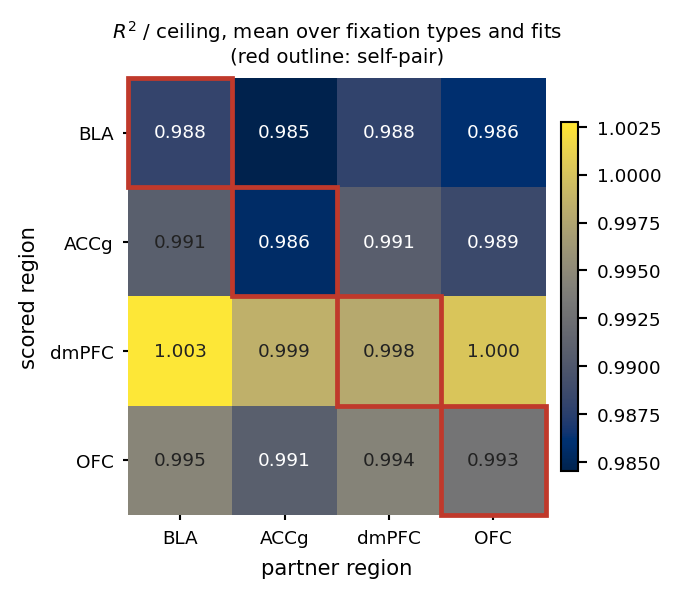

partner_region         accg     bla   dmpfc     ofc
scored_region arm                                  
accg          cross     NaN  0.9909  0.9907  0.9886
              self   0.9855     NaN     NaN     NaN
bla           cross  0.9845     NaN  0.9880  0.9859
              self      NaN  0.9881     NaN     NaN
dmpfc         cross  0.9985  1.0028     NaN  1.0002
              self      NaN     NaN  0.9979     NaN
ofc           cross  0.9908  0.9946  0.9944     NaN
              self      NaN     NaN     NaN  0.9930

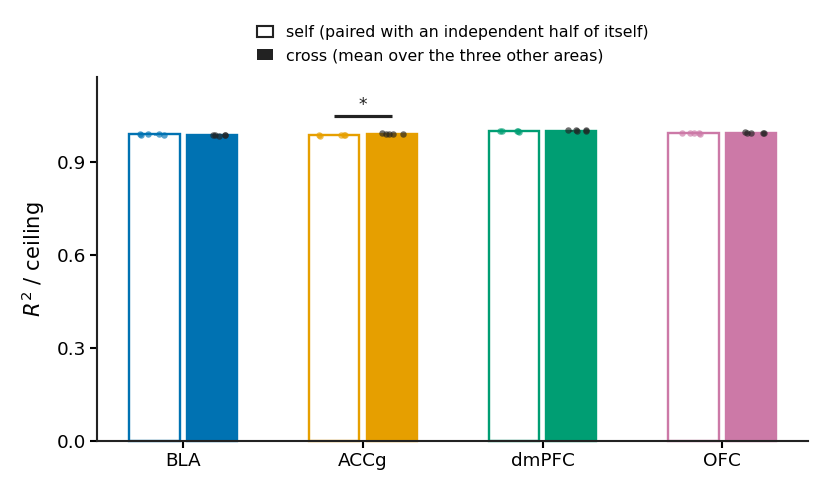

**Self-pair vs. cross-pair, per region** (mean over fits; positive `difference` means cross beats self):

self           cross        
                 mean     std    mean     std
scored_region                                
accg           0.9855  0.0009  0.9901  0.0013
bla            0.9881  0.0010  0.9861  0.0015
dmpfc          0.9979  0.0004  1.0005  0.0015
ofc            0.9930  0.0011  0.9933  0.0014

**Tests:**

,scored_region,n,mean_a,mean_b,difference,statistic,p,p_holm,stars
0,accg,5,0.99008,0.98553,0.00455,6.38190,0.00309,0.01237,*
1,bla,5,0.98614,0.98811,-0.00197,-2.84744,0.04652,0.09303,
2,dmpfc,5,1.00051,0.99788,0.00263,3.88934,0.01770,0.05310,
3,ofc,5,0.99327,0.99297,0.00030,0.41795,0.69744,0.69744,


In [5]:
if matrix_fit is not None:
    show(pviz.plot_partner_identity_matrix(matrix_fit), "fig01_matrix")
    display(matrix_fit.groupby(["scored_region", "partner_region", "arm"])["r2_vs_ceiling"].mean()
            .unstack("partner_region").round(4))

    self_vs_cross = pid.self_vs_cross_per_seed(matrix_fit)
    long = self_vs_cross.melt(id_vars=["scored_region", "seed"], value_vars=["self", "cross"],
                              var_name="arm", value_name="value")
    region_tests = ch.paired_contrasts(long, value="value", group="arm", unit="seed",
                                       by="scored_region", pairs=[("cross", "self")])
    show(pviz.plot_self_vs_cross_by_region(long, region_tests), "fig02_self_vs_cross_by_region")
    md("**Self-pair vs. cross-pair, per region** (mean over fits; positive `difference` means cross beats self):")
    display(self_vs_cross.groupby("scored_region")[["self", "cross"]].agg(["mean", "std"]).round(4))
    md("**Tests:**")
    display(region_tests[["scored_region", "n", "mean_a", "mean_b", "difference", "statistic", "p", "p_holm", "stars"]].round(5)
            if not region_tests.empty else region_tests)

## 5. Which fixation type is most affected?

The same self-vs-cross contrast, now per fixation type with regions pooled: does
interactive face lose more from being paired with an independent half of itself than the
other two fixation types do?

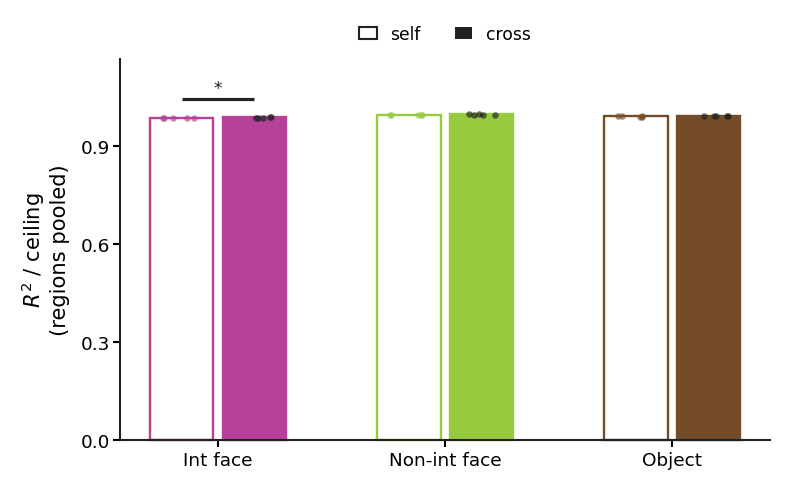

**Self vs. cross per fixation type** (regions pooled):

mean             std        
arm                    cross    self   cross    self
condition                                           
face_interactive      0.9880  0.9863  0.0008  0.0004
face_non_interactive  0.9972  0.9958  0.0010  0.0004
object                0.9923  0.9913  0.0010  0.0004

**Tests:**

,condition,n,mean_a,mean_b,difference,statistic,p,p_holm,stars
0,face_interactive,5,0.98801,0.98630,0.00170,4.41296,0.01157,0.03472,*
1,face_non_interactive,5,0.99721,0.99578,0.00143,3.05571,0.03782,0.07563,
2,object,5,0.99228,0.99128,0.00099,2.13145,0.10005,0.10005,


In [6]:
if matrix_fit is not None:
    cond_per_fit = matrix_fit.groupby(["arm", "seed", "condition"])["r2_vs_ceiling"].mean().reset_index()
    cond_tests = ch.paired_contrasts(cond_per_fit, value="r2_vs_ceiling", group="arm", unit="seed",
                                     by="condition", pairs=[("cross", "self")])
    show(pviz.plot_self_vs_cross_by_condition(matrix_fit, cond_tests), "fig03_self_vs_cross_by_condition")
    md("**Self vs. cross per fixation type** (regions pooled):")
    display(cond_per_fit.groupby(["condition", "arm"])["r2_vs_ceiling"].agg(["mean", "std"]).unstack("arm").round(4))
    md("**Tests:**")
    display(cond_tests[["condition", "n", "mean_a", "mean_b", "difference", "statistic", "p", "p_holm", "stars"]].round(5)
            if not cond_tests.empty else cond_tests)

## 6. Which region -- or which pair -- is most affected?

Figure 2 already shows whether the self-vs-cross gap is uniform across regions or
concentrated in one or two. This section adds the finer-grained read: for each scored
region, which *specific* partner helps most, and does the identity of the partner (not just
"a partner exists") matter within the six cross-pairs?

In [7]:
if matrix_fit is not None:
    per_partner = matrix_fit.groupby(["scored_region", "partner_region", "arm", "seed"])["r2_vs_ceiling"].mean().reset_index()
    md("**Every partner, per scored region** (mean over fits and fixation types; the diagonal is the self-pair):")
    display(per_partner.groupby(["scored_region", "partner_region"])["r2_vs_ceiling"].mean().unstack("partner_region").round(4))

    cross_only = per_partner[per_partner["arm"] == "cross"]
    if cross_only["scored_region"].nunique() and (cross_only.groupby("scored_region")["partner_region"].nunique() >= 2).any():
        partner_tests = []
        for region, block in cross_only.groupby("scored_region"):
            wide = block.pivot(index="seed", columns="partner_region", values="r2_vs_ceiling")
            if wide.shape[1] >= 2 and wide.shape[0] >= 3:
                partners = list(wide.columns)
                partner_tests.append(
                    ch.welch_contrasts(block, value="r2_vs_ceiling", group="partner_region",
                                       pairs=[(partners[i], partners[j]) for i in range(len(partners)) for j in range(i + 1, len(partners))])
                    .assign(scored_region=region)
                )
        if partner_tests:
            partner_tests = pd.concat(partner_tests, ignore_index=True)
            md("**Does the specific cross-region partner matter, within the three real partners of one region?** "
               "(Welch's t between partners, Holm-corrected within each region; empty means no contrast reached significance):")
            display(partner_tests[partner_tests["significant"]][["scored_region", "a", "b", "difference", "p_holm", "stars"]]
                    if not partner_tests.empty else partner_tests)

**Every partner, per scored region** (mean over fits and fixation types; the diagonal is the self-pair):

partner_region,accg,bla,dmpfc,ofc
scored_region,,,,
accg,0.9855,0.9909,0.9907,0.9886
bla,0.9845,0.9881,0.9880,0.9859
dmpfc,0.9985,1.0028,0.9979,1.0002
ofc,0.9908,0.9946,0.9944,0.9930


**Does the specific cross-region partner matter, within the three real partners of one region?** (Welch's t between partners, Holm-corrected within each region; empty means no contrast reached significance):

,scored_region,a,b,difference,p_holm,stars
6,dmpfc,accg,bla,-0.004228,0.007458,**
9,ofc,accg,bla,-0.003839,0.045248,*
10,ofc,accg,dmpfc,-0.003589,0.045248,*


## 7. What the fits look like

Target-prominent, model-thin-grey overlays (the chapter's Figure 2 convention) for one
region's leading components, self-paired against its best cross-pair, across every seed.

Best cross-partner for BLA: **dmPFC** (`cross_bla_dmpfc`).

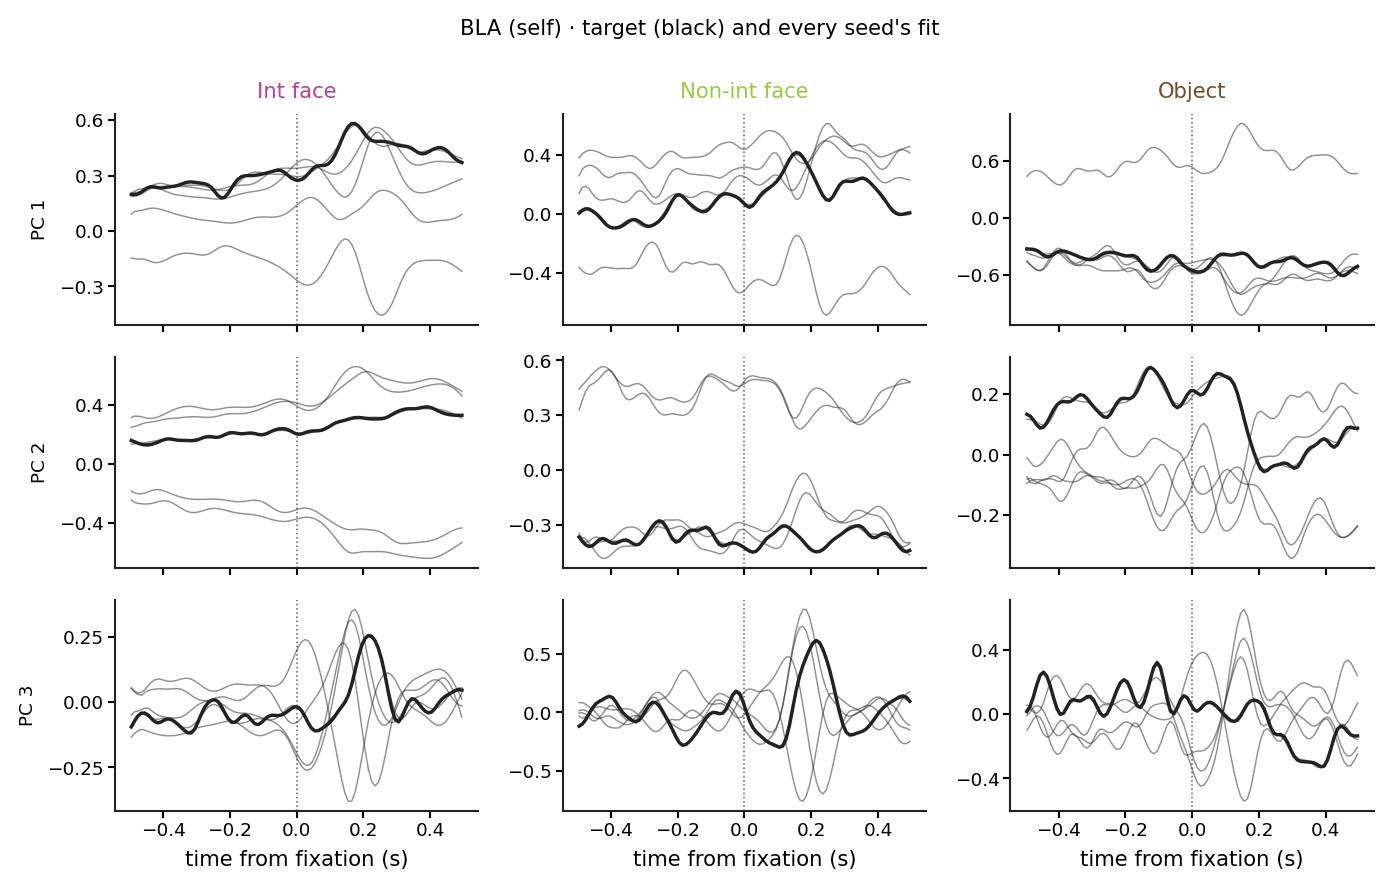

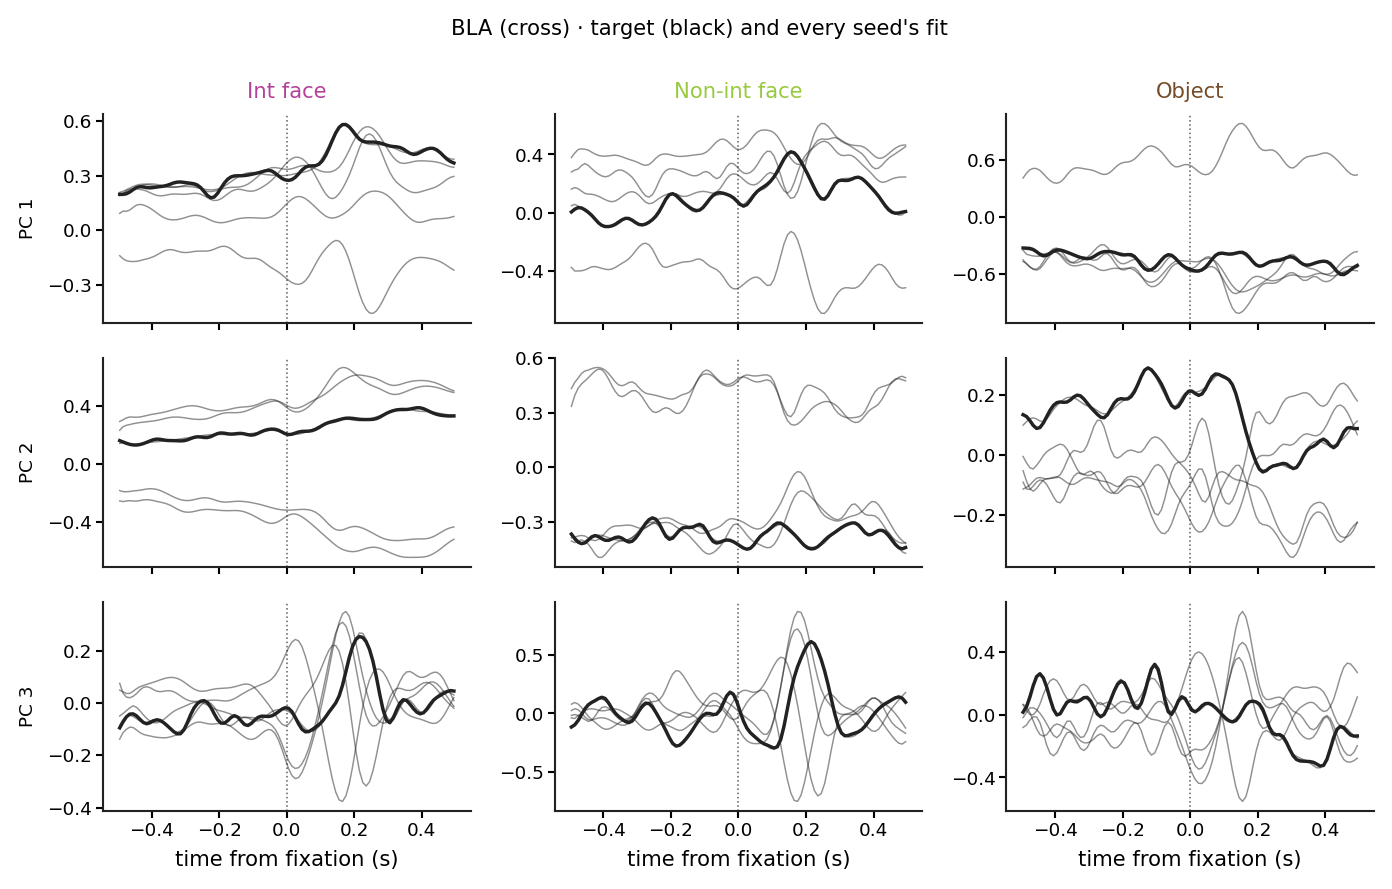

In [8]:
GALLERY_REGION = "bla"

if matrix_fit is not None:
    best_partner = (matrix_fit[(matrix_fit["scored_region"] == GALLERY_REGION) & (matrix_fit["arm"] == "cross")]
                    .groupby("partner_region")["r2_vs_ceiling"].mean().idxmax())
    self_label = f"self_{GALLERY_REGION}"
    cross_label = next(a.label for a in ARCHITECTURES if a.arm == "cross"
                       and {a.scored_region, a.partner_region} == {GALLERY_REGION, best_partner})
    md(f"Best cross-partner for {REGION_LABELS.get(GALLERY_REGION, GALLERY_REGION)}: "
       f"**{REGION_LABELS.get(best_partner, best_partner)}** (`{cross_label}`).")

    for label, arm in ((self_label, "self"), (cross_label, "cross")):
        block = done[done["label"] == label]
        virtual = f"{GALLERY_REGION}_a"
        traces = cached(f"gallery_{GALLERY_REGION}_{arm}",
                        lambda block=block, virtual=virtual: ens.reconstruction_traces(list(block["run_dir"]), region=virtual))
        if traces is not None and len(traces):
            show(eviz.plot_reconstruction_overlay(traces, arm=arm,
                 title=f"{REGION_LABELS.get(GALLERY_REGION, GALLERY_REGION)} ({arm}) · target (black) and every seed's fit"),
                 f"fig04_gallery_{GALLERY_REGION}_{arm}")

## 8. A rank-bottleneck sweep: is spare capacity hiding the effect?

Every cell in §4-§6 sits at 98.5-100.3% of ceiling regardless of arm. That is not a bug in
the acid test -- it is the same thing task 02's own rank grid found for the dense ladder:
a network needing only a rank-1 within-region recurrence and a rank-10 cross-region channel
(`w1_c10`, `02_rank_grid/selected_bottleneck.yaml`) already reaches 98% of ceiling on the
*full* population. `base_model.yaml`'s 40 dense hidden units per block are several times
that, so there is at most ~1.5% of ceiling left for a partner-identity effect to move in --
which is roughly the size of what §4 finds (ACC and interactive face, the two combinations
with the most headroom below ceiling, show the largest and only Holm-significant gaps, and
even those are a few tenths of a percent of ceiling).

This probes rather than commits: hold the within-region bottleneck at task 02's already-
selected `within_region_bottleneck_dim = 1`, and train only the two *endpoints* of the
cross-region rank -- **(1, 1)**, as tight as a channel can be, and **(1, 10)**, task 02's
own selection -- on two seeds rather than all five, since at this stage the question is
only "does tightening the channel open up a visibly bigger self-vs-cross gap at all",
not yet a Holm-corrected effect size. That is 2 cross-dims x 10 architectures x 2 seeds =
**40** training runs, landing in their own `w1_c{cross_dim}` subtree alongside (not over)
the dense grid already trained; no new data preparation, since both probe seeds already
have a relabelled dataset from §1.

If (1, 1) shows a clearly larger, reproducible-across-both-seeds self-vs-cross gap than
(1, 10) -- which should itself land close to the dense grid's near-null result, since it is
close to what the dense ladder already uses -- that confirms spare capacity is masking a
real effect, and only then is it worth adding an intermediate cross dim (edit
`EXTRA_CROSS_DIMS` below) and widening `BOTTLENECK_SEEDS` toward the full five for a
properly powered read. If (1, 1) looks no different from (1, 10), a bottleneck is not the
answer and the dense grid's small gap is probably close to the true effect.

In [9]:
WITHIN_BOTTLENECK = 1              # task 02's own selection.
PROBE_CROSS_DIMS = [1, 10]         # the two endpoints: as tight as possible, and task 02's own choice.
EXTRA_CROSS_DIMS = []              # add an intermediate value (e.g. [5]) here once the probe says it's worth it.
CROSS_BOTTLENECK_DIMS = PROBE_CROSS_DIMS + EXTRA_CROSS_DIMS

BOTTLENECK_SEEDS = protocol.protocol_seeds(n_seeds=2)   # a prefix of SEEDS; widen toward SEEDS once a dim is chosen.

SUBMIT_BOTTLENECK = False   # <-- set to True to queue every missing cell across all cross dims as one array

flight_bn = sweep.in_flight_run_dirs(TASK_ROOT / "_jobs")
bottleneck_commands, bottleneck_run_dirs, bottleneck_inventory_parts = [], [], []
for cross_dim in CROSS_BOTTLENECK_DIMS:
    tag = f"w{WITHIN_BOTTLENECK}_c{cross_dim}"
    cmds, dirs = pid.job_commands(
        ARCHITECTURES, BOTTLENECK_SEEDS, root=TASK_ROOT, repo_root=repo_root, epochs=EPOCHS,
        exclude_run_dirs=flight_bn["run_dirs"], within_region_bottleneck_dim=WITHIN_BOTTLENECK,
        recurrent_bottleneck_dim=cross_dim, bottleneck_tag=tag,
    )
    inv = pid.index_runs(TASK_ROOT, ARCHITECTURES, BOTTLENECK_SEEDS, bottleneck_tag=tag)
    inv["cross_bottleneck_dim"] = cross_dim
    bottleneck_commands += cmds
    bottleneck_run_dirs += dirs
    bottleneck_inventory_parts.append(inv)
bottleneck_inventory = pd.concat(bottleneck_inventory_parts, ignore_index=True)

display(bottleneck_inventory.groupby("cross_bottleneck_dim")["complete"].agg(["sum", "count"])
        .rename(columns={"sum": "complete", "count": "total"}))
display(Markdown(
    f"**{int(bottleneck_inventory['complete'].sum())} complete**, **{len(bottleneck_commands)} queued or unqueued** "
    f"of {len(bottleneck_inventory)} ({len(CROSS_BOTTLENECK_DIMS)} cross-dims x {len(ARCHITECTURES)} architectures "
    f"x {len(BOTTLENECK_SEEDS)} seeds)."))

if SUBMIT_BOTTLENECK and bottleneck_commands:
    from datetime import datetime
    from dal_monte_2022_analysis.runtime.hpc.jobs import submit_dsq_array_job, write_job_file

    jobs_dir = TASK_ROOT / "_jobs"
    jobs_dir.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    job_file = jobs_dir / f"partner_identity_bottleneck_{stamp}.txt"
    write_job_file(job_file, bottleneck_commands)
    job_id = submit_dsq_array_job(
        job_file_path=job_file, sbatch_script_path=jobs_dir / f"partner_identity_bottleneck_{stamp}.sh",
        log_dir=jobs_dir / "logs", job_name="mrnn_partner_identity_bottleneck", partition="psych_gpu",
        cpus_per_task=1, mem_per_cpu="12G", time_limit="06:00:00", gres="gpu:1",
    )
    sweep.record_submission(jobs_dir, job_id=job_id, run_dirs=bottleneck_run_dirs,
                            label=f"partner_identity_bottleneck {stamp}")
    (jobs_dir / "bottleneck_job_id.txt").write_text(str(job_id) + "\n")
    display(Markdown(f"Submitted **{len(bottleneck_commands)}** runs as array **{job_id}**."))
elif bottleneck_commands:
    display(Markdown("`SUBMIT_BOTTLENECK` is **False** -- nothing was submitted."))
elif int(bottleneck_inventory["complete"].sum()) == len(bottleneck_inventory):
    display(Markdown("The bottleneck sweep is fully trained."))
else:
    display(Markdown("Every missing cell already has a job in flight; nothing new to queue."))

,complete,total
cross_bottleneck_dim,,
1,20,20
10,20,20


**40 complete**, **0 queued or unqueued** of 40 (2 cross-dims x 10 architectures x 2 seeds).

The bottleneck sweep is fully trained.

## 9. Does tightening the channel affect a particular region or fixation type more?

Three figures, self drawn hollow and cross filled throughout: the headline self-vs-cross
gap at each cross-region rank, pooling everything; the same gap broken out by scored
region; and by fixation type. A region or fixation type whose bars separate more at rank 1
than at rank 10 is the one the dense grid's spare capacity was hiding. The gallery at the
end shows what that separation actually looks like in the traces themselves, for BLA's
leading component at the tightest rank probed.

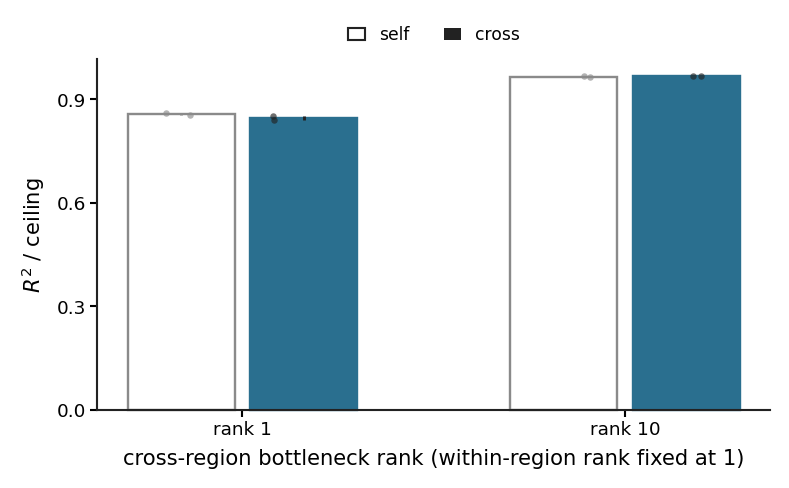

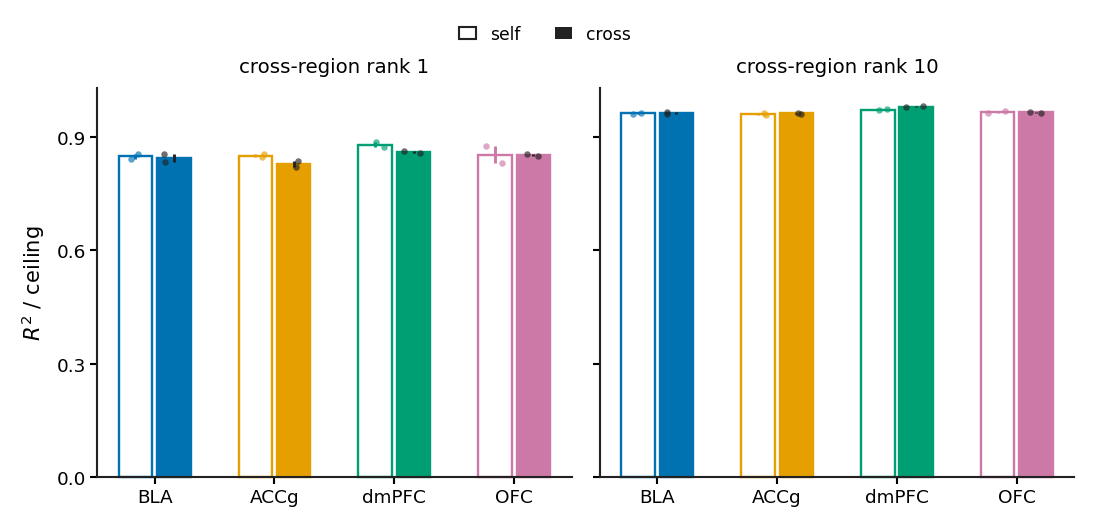

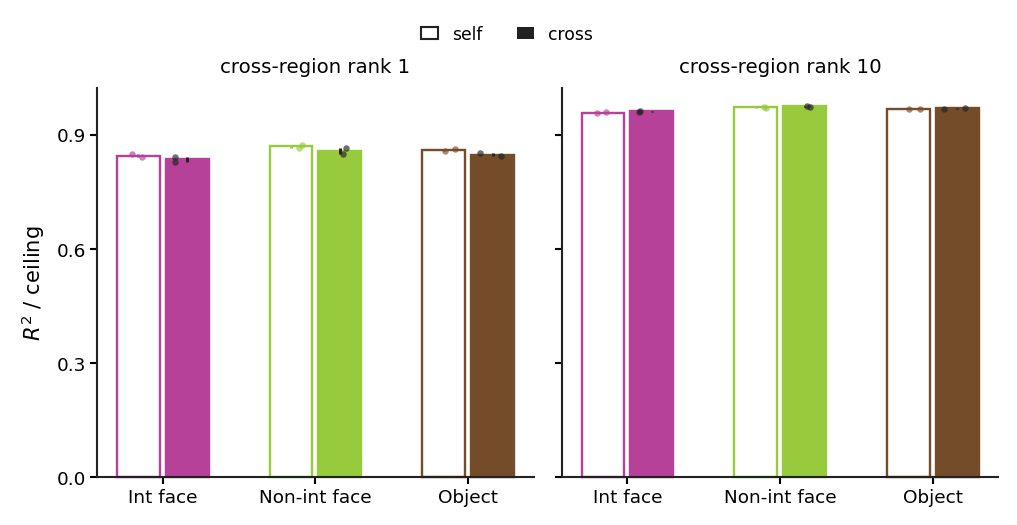

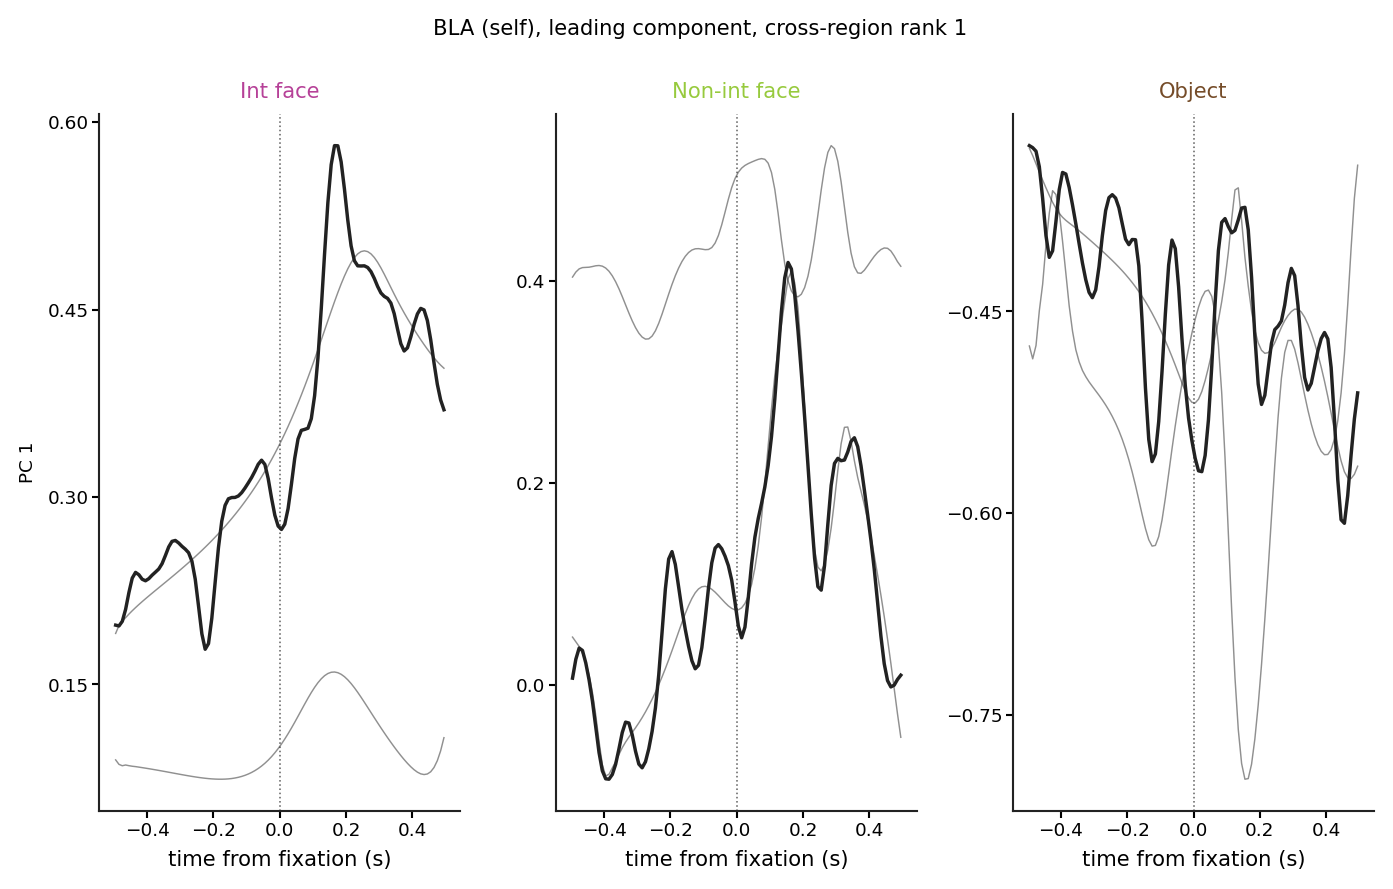

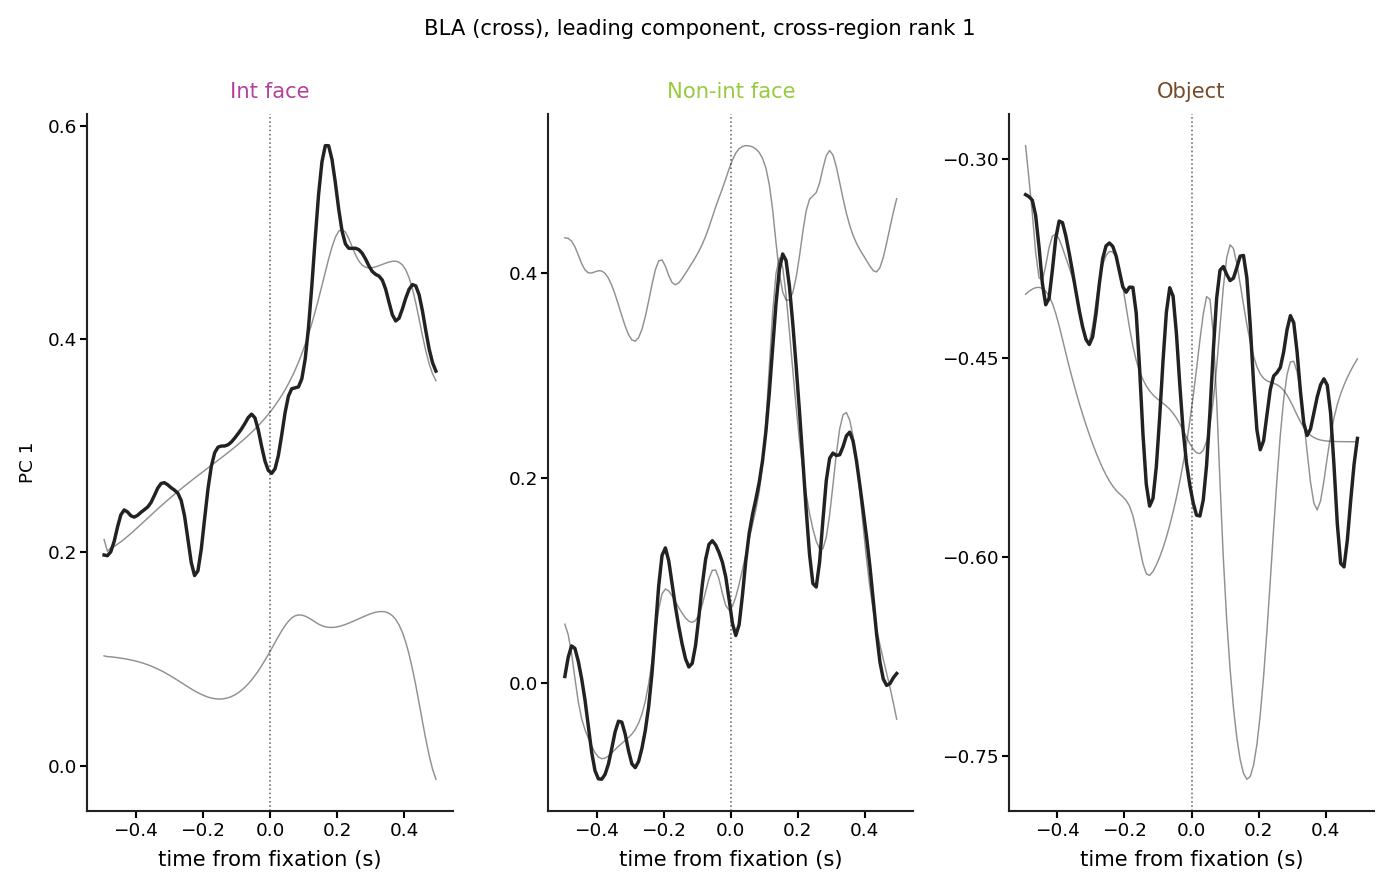

In [10]:
bottleneck_matrix_fits = {}
for cross_dim in CROSS_BOTTLENECK_DIMS:
    tag = f"w{WITHIN_BOTTLENECK}_c{cross_dim}"
    done_bn = bottleneck_inventory[(bottleneck_inventory["cross_bottleneck_dim"] == cross_dim)
                                   & (bottleneck_inventory["complete"])]
    if done_bn.empty:
        continue

    def build_ceiling_bn(done_bn=done_bn):
        frames = []
        for seed in BOTTLENECK_SEEDS:
            self_dirs = done_bn[(done_bn["arm"] == "self") & (done_bn["seed"] == str(seed))]
            if self_dirs.empty:
                continue
            per_seed = pd.concat(
                [pid.ceiling_by_cell_for_seed(row.run_dir, unit_ceiling) for row in self_dirs.itertuples()],
                ignore_index=True)
            per_seed["seed"] = str(seed)
            frames.append(per_seed)
        return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

    ceiling_cell_bn = cached(f"ceiling_by_cell_{tag}", build_ceiling_bn)
    if ceiling_cell_bn is None or ceiling_cell_bn.empty:
        continue
    lookup_bn = pid.ceiling_lookup(ceiling_cell_bn.groupby(["region", "condition"])["reliability"].mean().reset_index())
    from dal_monte_2022_analysis.ephys.analysis.fixation_mrnn_sweep import score_variant_fit
    fit_bn = cached(f"fit_{tag}",
                    lambda done_bn=done_bn, lookup_bn=lookup_bn: score_variant_fit(done_bn, ceiling_by_region={}, ceiling_by_cell=lookup_bn))
    bottleneck_matrix_fits[cross_dim] = cached(f"matrix_fit_{tag}", lambda fit_bn=fit_bn: pid.matrix_fit_table(fit_bn, ARCHITECTURES))

if not bottleneck_matrix_fits:
    display(Markdown("*Nothing in the §8 sweep is trained yet -- set `SUBMIT_BOTTLENECK = True` there first.*"))
    bottleneck_fit_all = None
else:
    bottleneck_fit_all = pd.concat(
        [mf.assign(cross_bottleneck_dim=cross_dim) for cross_dim, mf in bottleneck_matrix_fits.items()], ignore_index=True)

    dim_long = (bottleneck_fit_all.groupby(["cross_bottleneck_dim", "arm", "seed"])["r2_vs_ceiling"].mean()
               .reset_index().rename(columns={"r2_vs_ceiling": "value"}))
    dim_tests = ch.paired_contrasts(dim_long, value="value", group="arm", unit="seed",
                                    by="cross_bottleneck_dim", pairs=[("cross", "self")])
    show(pviz.plot_bottleneck_self_vs_cross(bottleneck_fit_all, dim_tests), "fig05_bottleneck_self_vs_cross")
    show(pviz.plot_bottleneck_by_region(bottleneck_fit_all), "fig06_bottleneck_by_region")
    show(pviz.plot_bottleneck_by_condition(bottleneck_fit_all), "fig07_bottleneck_by_condition")

    tightest = min(CROSS_BOTTLENECK_DIMS)
    tag = f"w{WITHIN_BOTTLENECK}_c{tightest}"
    done_bn = bottleneck_inventory[(bottleneck_inventory["cross_bottleneck_dim"] == tightest)
                                   & (bottleneck_inventory["complete"])]
    mf = bottleneck_matrix_fits.get(tightest)
    if done_bn.empty or mf is None or mf.empty:
        display(Markdown(f"*No completed cells at cross-region rank {tightest} yet for the gallery.*"))
    else:
        GALLERY_REGION = "bla"
        best_partner = (mf[(mf["scored_region"] == GALLERY_REGION) & (mf["arm"] == "cross")]
                        .groupby("partner_region")["r2_vs_ceiling"].mean().idxmax())
        self_label = f"self_{GALLERY_REGION}"
        cross_label = next(a.label for a in ARCHITECTURES if a.arm == "cross"
                           and {a.scored_region, a.partner_region} == {GALLERY_REGION, best_partner})
        for label, arm in ((self_label, "self"), (cross_label, "cross")):
            block = done_bn[done_bn["label"] == label]
            virtual = f"{GALLERY_REGION}_a"
            traces = cached(f"gallery_{tag}_{GALLERY_REGION}_{arm}",
                            lambda block=block, virtual=virtual: ens.reconstruction_traces(list(block["run_dir"]), region=virtual, indices=(0,)))
            if traces is not None and len(traces):
                show(eviz.plot_reconstruction_overlay(
                        traces, arm=arm,
                        title=f"{REGION_LABELS.get(GALLERY_REGION, GALLERY_REGION)} ({arm}), leading component, cross-region rank {tightest}"),
                     f"fig08_gallery_{tag}_{GALLERY_REGION}_{arm}")

## 10. Region-pair size asymmetry: does a tight cross-region channel cost more for mismatched pairs?

The six cross-pairs span better than a two-and-a-half-fold range in relative half size:
ACC-OFC are nearly matched (half sizes ~118 vs ~120, ratio 1.02), BLA-dmPFC are the most
mismatched (~269 vs ~94, ratio 2.87). Each self-pair is architecturally its own matched
anchor at ratio 1.0. If a narrow cross-region channel is a bigger handicap when the two
partners carry very different amounts of information, cost (`1 - r2_vs_ceiling`) at the
tighter cross dims should climb with this ratio; if the channel's rank is what limits fit
and the size gap is not the relevant variable, it should not.

,region_a,region_b,half_size_a,half_size_b,size_ratio
0,ofc,ofc,120.5,120.5,1.000
1,bla,bla,268.5,268.5,1.000
2,dmpfc,dmpfc,93.5,93.5,1.000
3,accg,accg,118.0,118.0,1.000
4,accg,ofc,118.0,120.5,1.021
5,accg,dmpfc,118.0,93.5,1.262
6,dmpfc,ofc,93.5,120.5,1.289
7,bla,ofc,268.5,120.5,2.228
8,accg,bla,118.0,268.5,2.275
9,bla,dmpfc,268.5,93.5,2.872


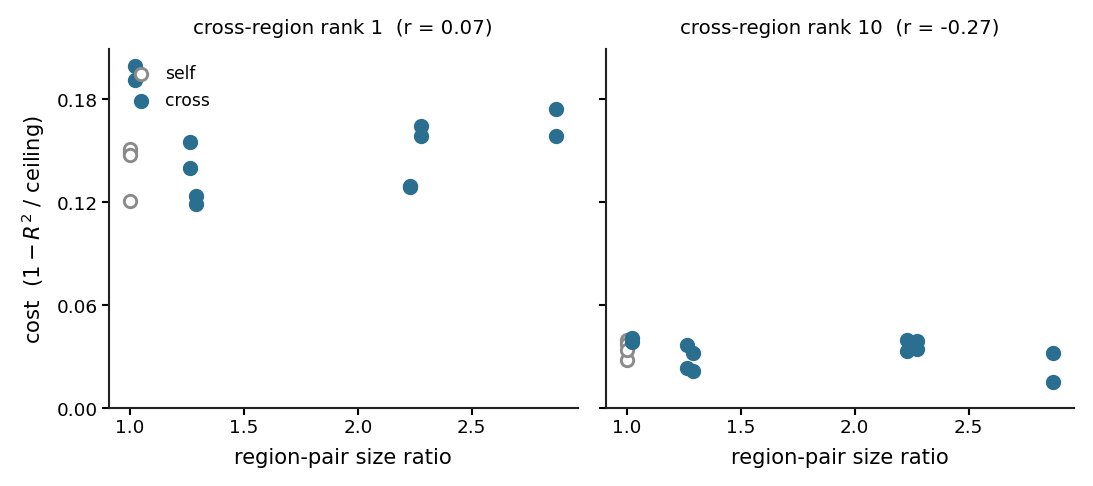

In [11]:
RELABELLED_ROOT = repo_root.parent / "local_data" / "dal_monte_2022" / "analysis_outputs" / pid.RELABELLED_INPUT_ROOT
ASYMMETRY = pid.region_pair_asymmetry(RELABELLED_ROOT, SEEDS)
display(ASYMMETRY.round(3))

if bottleneck_fit_all is None:
    display(Markdown("*Nothing in the §8 sweep is trained yet.*"))
else:
    per_pair = (bottleneck_fit_all.groupby(["cross_bottleneck_dim", "scored_region", "partner_region", "arm"])
               ["r2_vs_ceiling"].mean().reset_index())
    cost_rows = []
    for row in per_pair.itertuples():
        a, b = sorted((row.scored_region, row.partner_region))
        ratio = 1.0 if row.arm == "self" else float(
            ASYMMETRY[(ASYMMETRY["region_a"] == a) & (ASYMMETRY["region_b"] == b)]["size_ratio"].iloc[0])
        cost_rows.append({"cross_bottleneck_dim": row.cross_bottleneck_dim, "scored_region": row.scored_region,
                          "partner_region": row.partner_region, "arm": row.arm,
                          "size_ratio": ratio, "cost": 1.0 - row.r2_vs_ceiling})
    cost = pd.DataFrame(cost_rows)
    show(pviz.plot_bottleneck_cost_vs_asymmetry(cost), "fig09_bottleneck_cost_vs_asymmetry")

## 11. Reading the result

Four things this task can support, in order of what they would mean:

1. **Whether the ladder's "the network helps" result survives matched parameter count.**
   The self-vs-cross contrast in §4, per region and Holm-corrected across all four. If
   self-pairs reproduce a region about as well as cross-pairs do, the ladder's gain was
   mostly extra capacity; if cross-pairs reliably win, the partner's content matters.
2. **Whether that matters more for one fixation type.** §5, mirroring how the chapter reads
   "does this constraint cost interactive face more" -- here the constraint is *which*
   partner, not how narrow the channel is.
3. **Whether it is one region, or a specific pair, carrying the effect.** §6's partner
   breakdown is descriptive at five seeds; a genuine ranking among the three real partners
   of one region needs more seeds than a coarse self-vs-cross average does, exactly the
   kind of question task 01's pair matrix could not resolve either.
4. **Whether the dense network's spare capacity is masking a larger effect, and whether
   that masking is worse for size-mismatched pairs.** §8-§10's two-point, two-seed probe
   at full connectivity's every cell already sits within ~1.5% of ceiling, leaving little
   room for architecture to matter regardless of whether it truly doesn't or the network
   simply has enough capacity to route around a missing or wrong partner. If (1, 1) shows
   a bigger, both-seeds-agree gap than (1, 10) -- especially one that costs mismatched
   pairs (BLA-dmPFC) more than matched ones (ACC-OFC) -- the dense result understates a
   real, size-dependent dependence on partner identity, and it is worth adding an
   intermediate cross dim and the remaining seeds. If the two probe points look alike, a
   bottleneck is not the answer and the dense grid's small gap is probably close to the
   true effect.

At five seeds this task can say whether the self-vs-cross gap exists and roughly how big it
is; it is underpowered for anything finer (which specific partner, whether the effect is
uniform across regions) unless it turns out to be large. The grid is written so extending
`SEEDS` to ten, or `BOTTLENECK_SEEDS`/`CROSS_BOTTLENECK_DIMS` to a fuller sweep, costs only
the new fits, not a rebuild of anything already trained.